In [44]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sw
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [ ]:
main_data = pd.read_csv("../data/dataset.csv")
data = main_data.copy()
pd.set_option("display.max_columns",None)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

# Domain Analysis

In [4]:
data.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,0.125683,0.404372,0.139344,0.546448,0.336066,1.368852,1.956284,0.527322,1.289617,0.663934,0.991803,0.633880,0.295082,0.363388,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,0.331946,0.869818,0.411790,0.815451,0.853139,1.104418,0.712512,0.757116,0.917562,1.056829,1.162161,1.034924,0.670578,0.759721,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [5]:
data.describe(include='O')

,Age
count,366
unique,61
top,40
freq,17


In [6]:
data.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [7]:
data.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [8]:
for col in data:
    print(f"{col} :- ", data[col].value_counts())
    print("\n")

erythema :-  erythema
2    215
3     90
1     57
0      4
Name: count, dtype: int64


scaling :-  scaling
2    195
1    111
3     52
0      8
Name: count, dtype: int64


definite_borders :-  definite_borders
2    168
1     93
0     59
3     46
Name: count, dtype: int64


itching :-  itching
0    118
2    100
3     76
1     72
Name: count, dtype: int64


koebner_phenomenon :-  koebner_phenomenon
0    224
1     70
2     54
3     18
Name: count, dtype: int64


polygonal_papules :-  polygonal_papules
0    297
2     41
3     27
1      1
Name: count, dtype: int64


follicular_papules :-  follicular_papules
0    333
2     16
1     11
3      6
Name: count, dtype: int64


oral_mucosal_involvement :-  oral_mucosal_involvement
0    299
2     45
3     13
1      9
Name: count, dtype: int64


knee_and_elbow_involvement :-  knee_and_elbow_involvement
0    251
2     64
1     28
3     23
Name: count, dtype: int64


scalp_involvement :-  scalp_involvement
0    264
2     56
1     30
3     16
Name: count,

In [9]:
for col in data:
    print(f"{col} :- ", data[col].unique())

erythema :-  [2 3 1 0]
scaling :-  [2 3 1 0]
definite_borders :-  [0 3 2 1]
itching :-  [3 2 0 1]
koebner_phenomenon :-  [0 1 2 3]
polygonal_papules :-  [0 3 2 1]
follicular_papules :-  [0 3 1 2]
oral_mucosal_involvement :-  [0 3 2 1]
knee_and_elbow_involvement :-  [1 0 3 2]
scalp_involvement :-  [0 1 2 3]
family_history :-  [0 1]
melanin_incontinence :-  [0 1 2 3]
eosinophils_in_the_infiltrate :-  [0 2 1]
PNL_infiltrate :-  [0 1 3 2]
fibrosis_of_the_papillary_dermis :-  [0 3 1 2]
exocytosis :-  [3 1 0 2]
acanthosis :-  [2 3 1 0]
hyperkeratosis :-  [0 2 1 3]
parakeratosis :-  [0 2 3 1]
clubbing_of_the_rete_ridges :-  [0 2 1 3]
elongation_of_the_rete_ridges :-  [0 2 3 1]
thinning_of_the_suprapapillary_epidermis :-  [0 2 3 1]
spongiform_pustule :-  [0 2 1 3]
munro_microabcess :-  [0 1 2 3]
focal_hypergranulosis :-  [0 2 3 1]
disappearance_of_the_granular_layer :-  [0 3 2 1]
vacuolisation_and_damage_of_basal_layer :-  [0 2 3 1]
spongiosis :-  [3 0 2 1]
saw-tooth_appearance_of_retes :-  [0

In [10]:
# age have value ? it means need to change it

In [11]:
data[data['Age'] == '?']

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
33,2,2,1,0,0,0,0,0,1,0,1,0,0,2,0,0,2,1,2,2,1,2,0,1,0,0,0,0,0,0,0,0,0,?,1
34,2,1,0,0,2,0,0,0,0,0,0,0,0,0,0,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,?,4
35,2,2,1,2,0,0,0,0,0,0,0,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,?,2
36,2,1,2,3,2,3,0,2,0,0,1,1,0,0,0,2,1,1,2,0,0,0,0,0,1,0,2,0,2,0,0,0,3,?,3
262,2,1,0,2,0,0,0,0,0,0,0,0,0,0,2,1,3,2,2,1,3,0,0,0,0,0,0,2,0,0,0,3,0,?,5
263,1,1,1,3,0,0,0,0,0,0,0,0,0,0,3,2,3,1,2,2,2,0,0,0,0,0,0,3,0,0,0,2,0,?,5
264,1,1,0,2,0,0,0,0,1,0,0,0,0,0,3,2,3,2,1,1,3,0,0,0,0,0,0,2,0,0,0,3,0,?,5
265,1,1,0,3,0,0,0,0,0,0,0,0,0,0,2,1,3,1,1,0,2,0,1,0,0,0,0,2,0,0,0,3,0,?,5


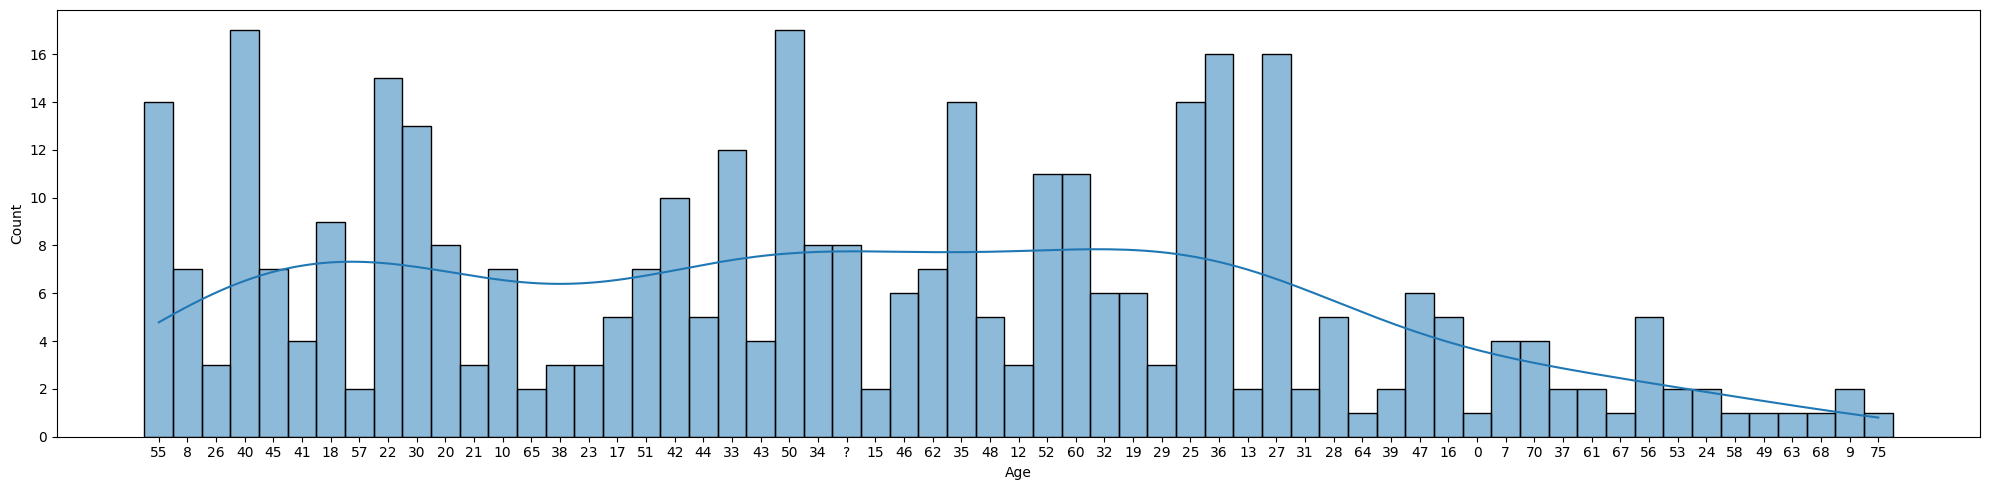

In [12]:
plt.figure(figsize=(20,5))
sns.histplot(x=data.Age, kde=1)
plt.tight_layout()
plt.show()

In [13]:
data['Age'].value_counts()

Age
40    17
50    17
36    16
27    16
22    15
      ..
58     1
49     1
63     1
68     1
75     1
Name: count, Length: 61, dtype: int64

In [14]:
data['Age'] = data['Age'].replace("?", 40)

In [15]:
data[data['Age'] == '?']

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class


In [16]:
data['Age'] = data['Age'].astype('int64')

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   erythema                                  366 non-null    int64
 1   scaling                                   366 non-null    int64
 2   definite_borders                          366 non-null    int64
 3   itching                                   366 non-null    int64
 4   koebner_phenomenon                        366 non-null    int64
 5   polygonal_papules                         366 non-null    int64
 6   follicular_papules                        366 non-null    int64
 7   oral_mucosal_involvement                  366 non-null    int64
 8   knee_and_elbow_involvement                366 non-null    int64
 9   scalp_involvement                         366 non-null    int64
 10  family_history                            366 non-null    int6

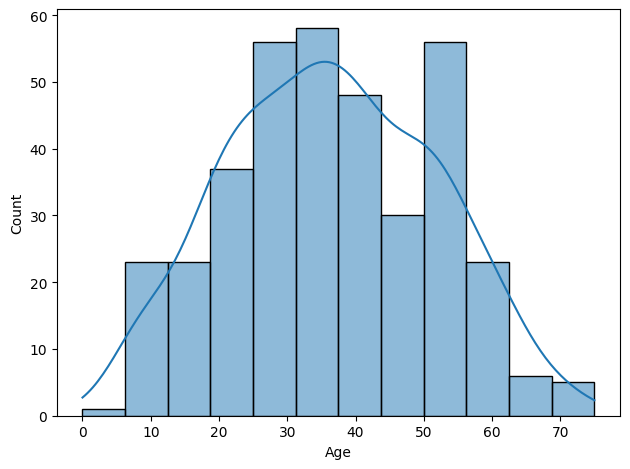

In [18]:
sns.histplot(x=data.Age, kde=1)
plt.tight_layout()
plt.show()

# EDA

In [19]:
report = sw.analyze(data)
report.show_html("univariant_analyze.html")

                                             |                                             | [  0%]   00:00 ->…

Report univariant_analyze.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


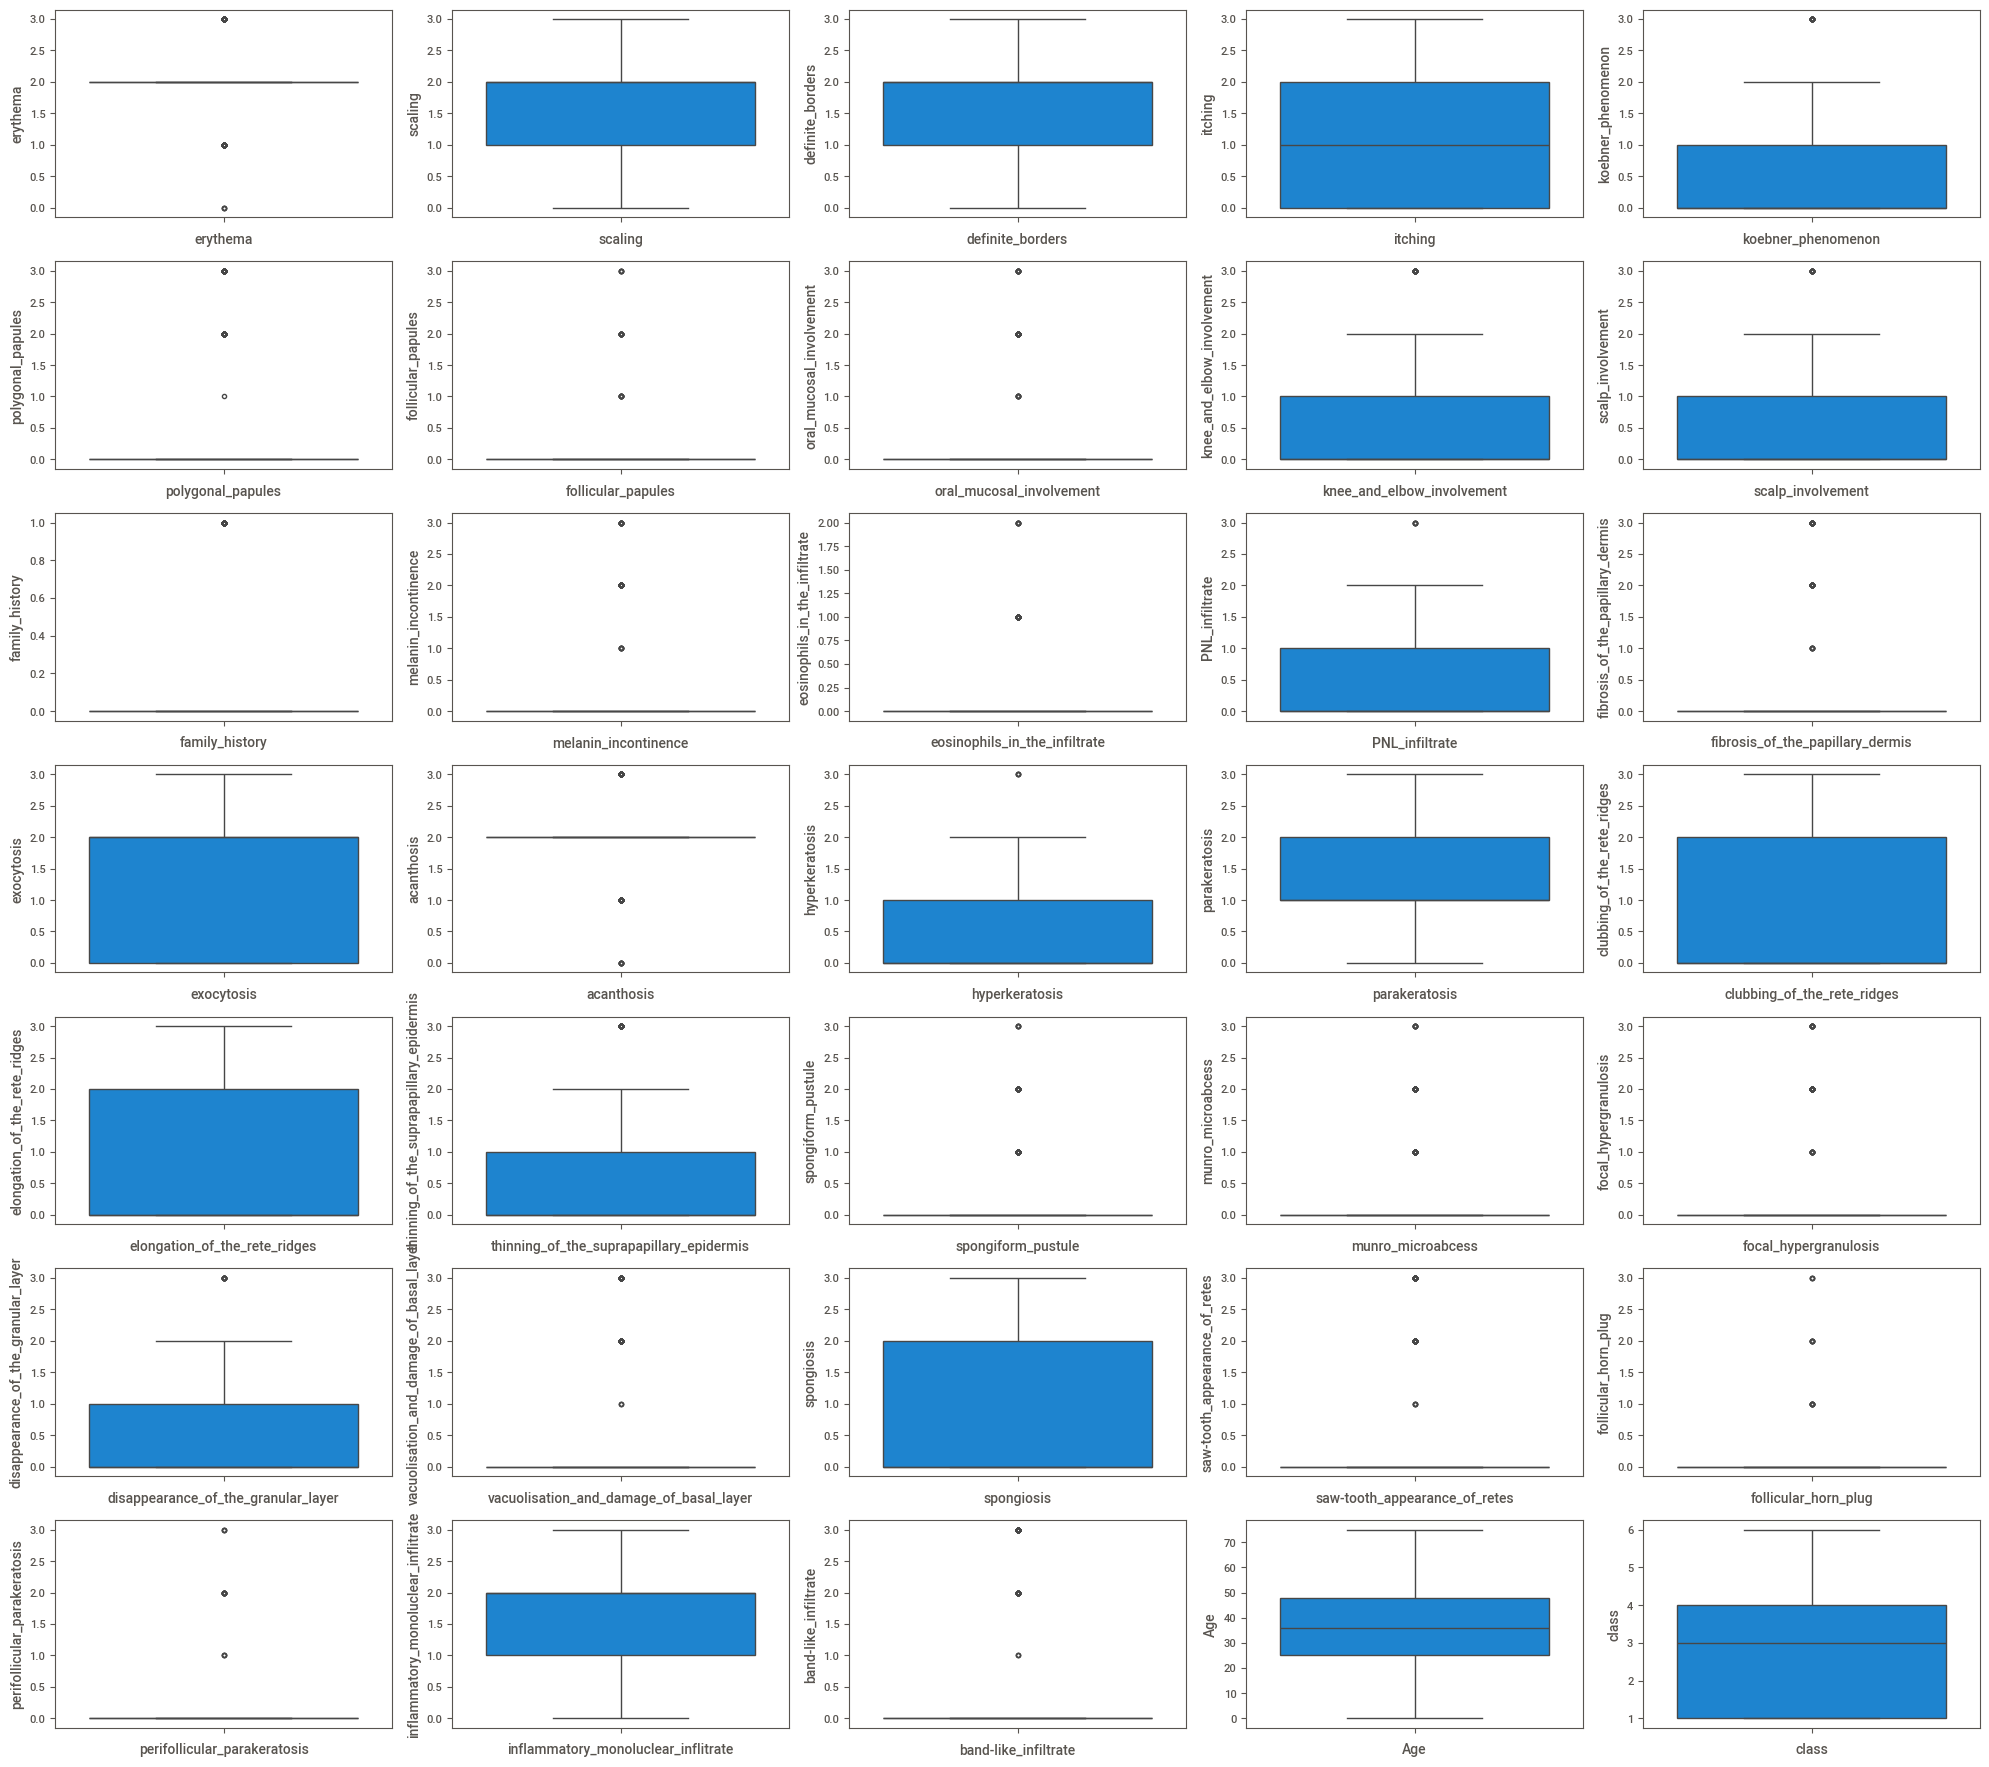

In [20]:
plt.figure(figsize = (20,20))
i = 1
for col in data:
    ax = plt.subplot(8,5,i)
    sns.boxplot(data[col])
    plt.xlabel(col)
    i = i+1

plt.tight_layout()
plt.show()

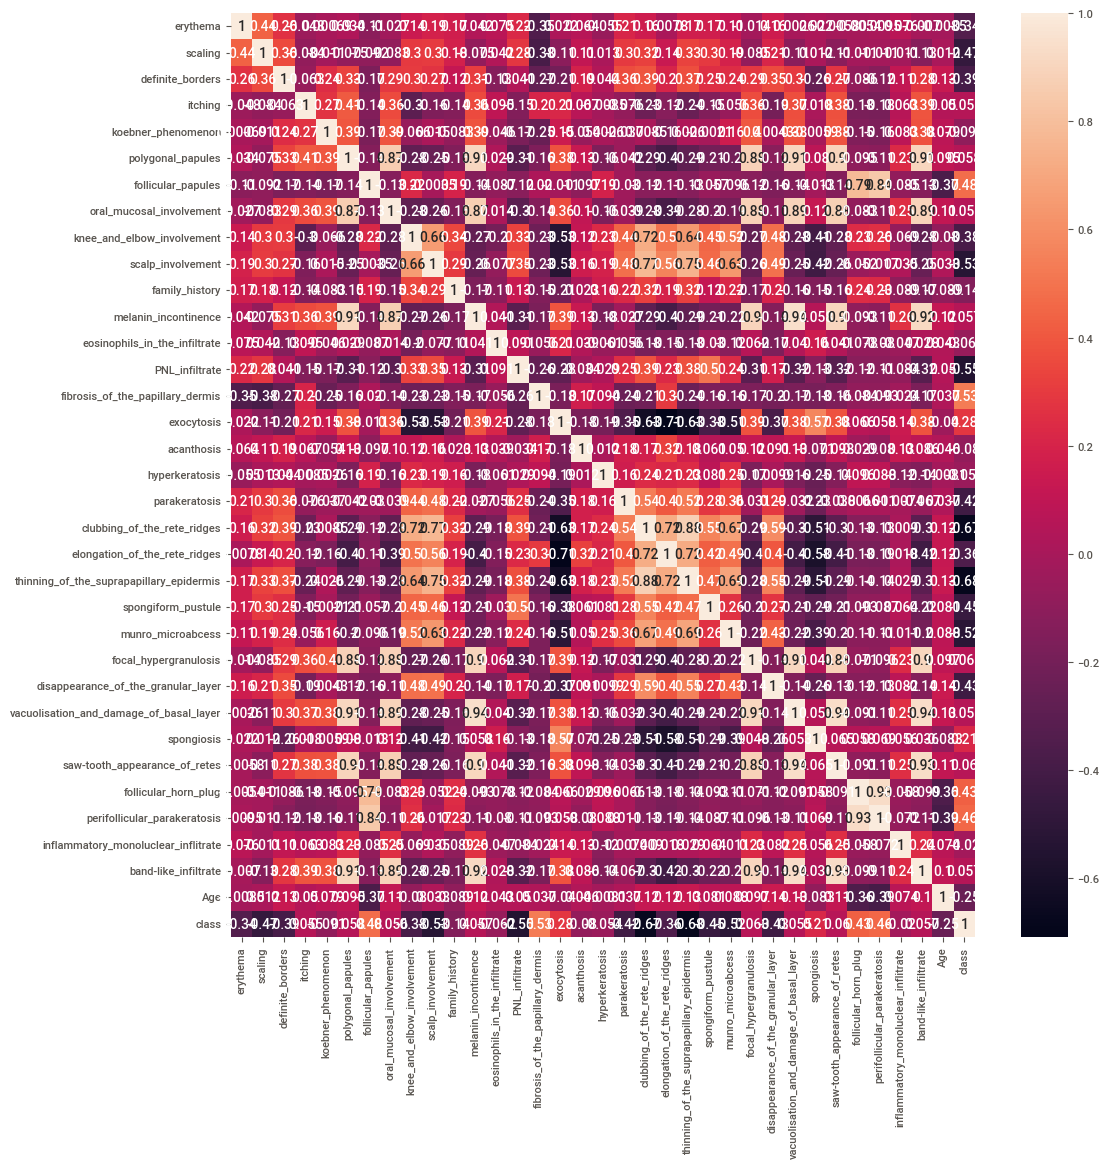

In [21]:
plt.figure(figsize=(12,12))
sns.heatmap(data.corr(),annot=True)
plt.show()

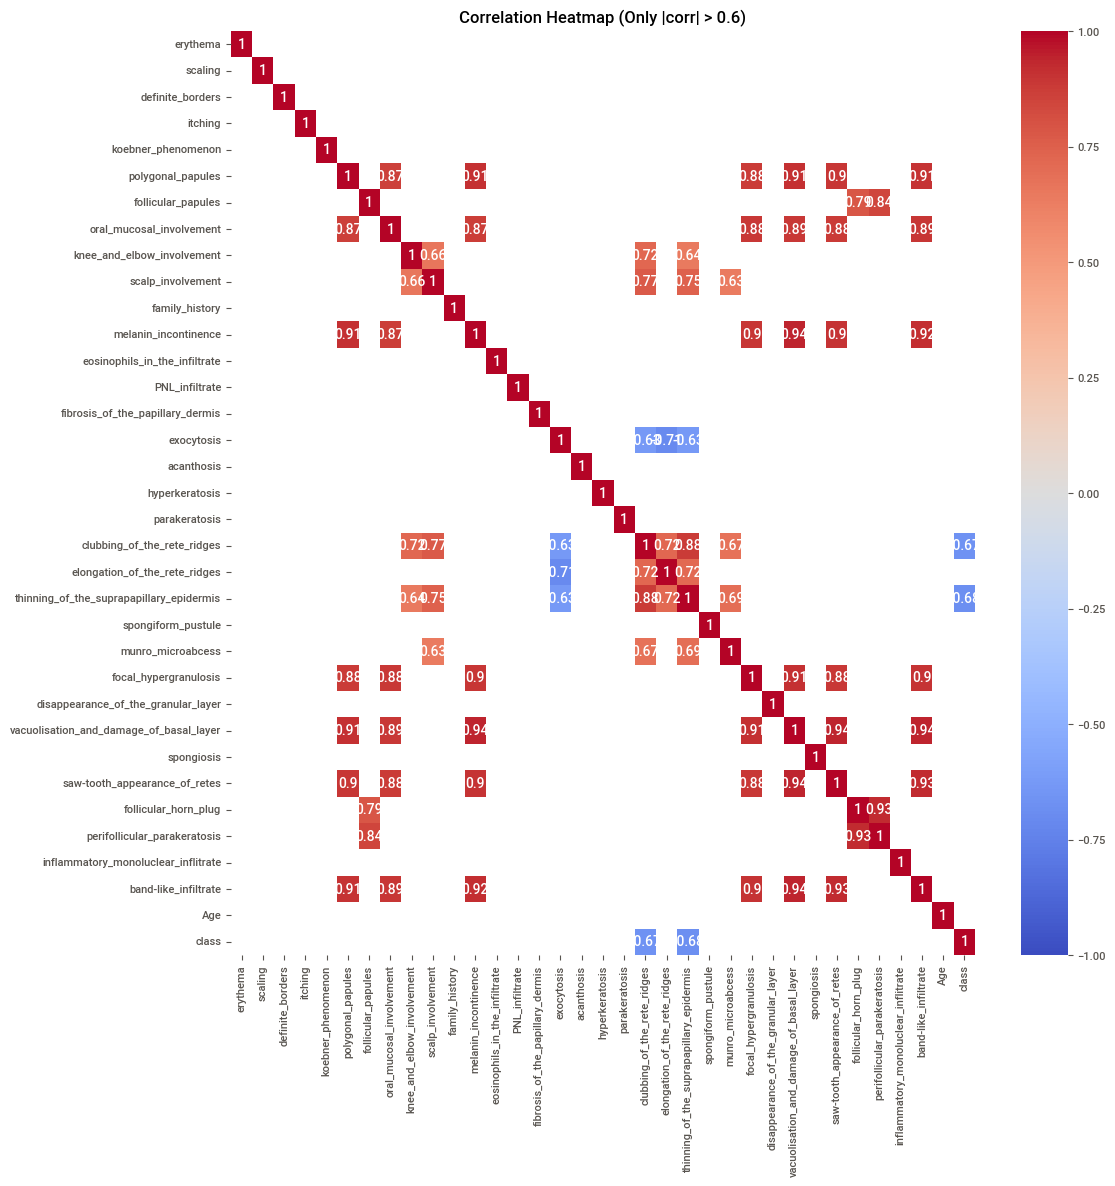

In [22]:
corr = data.corr()

# keep only correlations > 0.6 or < -0.6
filtered = corr[(corr.abs() > 0.6)]

filtered = filtered.dropna(how='all', axis=0)
filtered = filtered.dropna(how='all', axis=1)

plt.figure(figsize=(12, 12))
sns.heatmap(filtered, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Only |corr| > 0.6)")
plt.show()

### need to remove some column which have highly correlated with each other.

* thinning_of_suprapapillary_epidermis
* clubbing_of_rete_ridges
* spongiform_pustule
* band_like_infiltrate
* acanthosis

In [23]:
data.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [24]:
drop_list = ['focal_hypergranulosis', 'vacuolisation_and_damage_of_basal_layer', 'saw-tooth_appearance_of_retes','thinning_of_the_suprapapillary_epidermis', 
             'clubbing_of_the_rete_ridges','spongiform_pustule', 'band-like_infiltrate', 'acanthosis', 'perifollicular_parakeratosis', 'polygonal_papules']

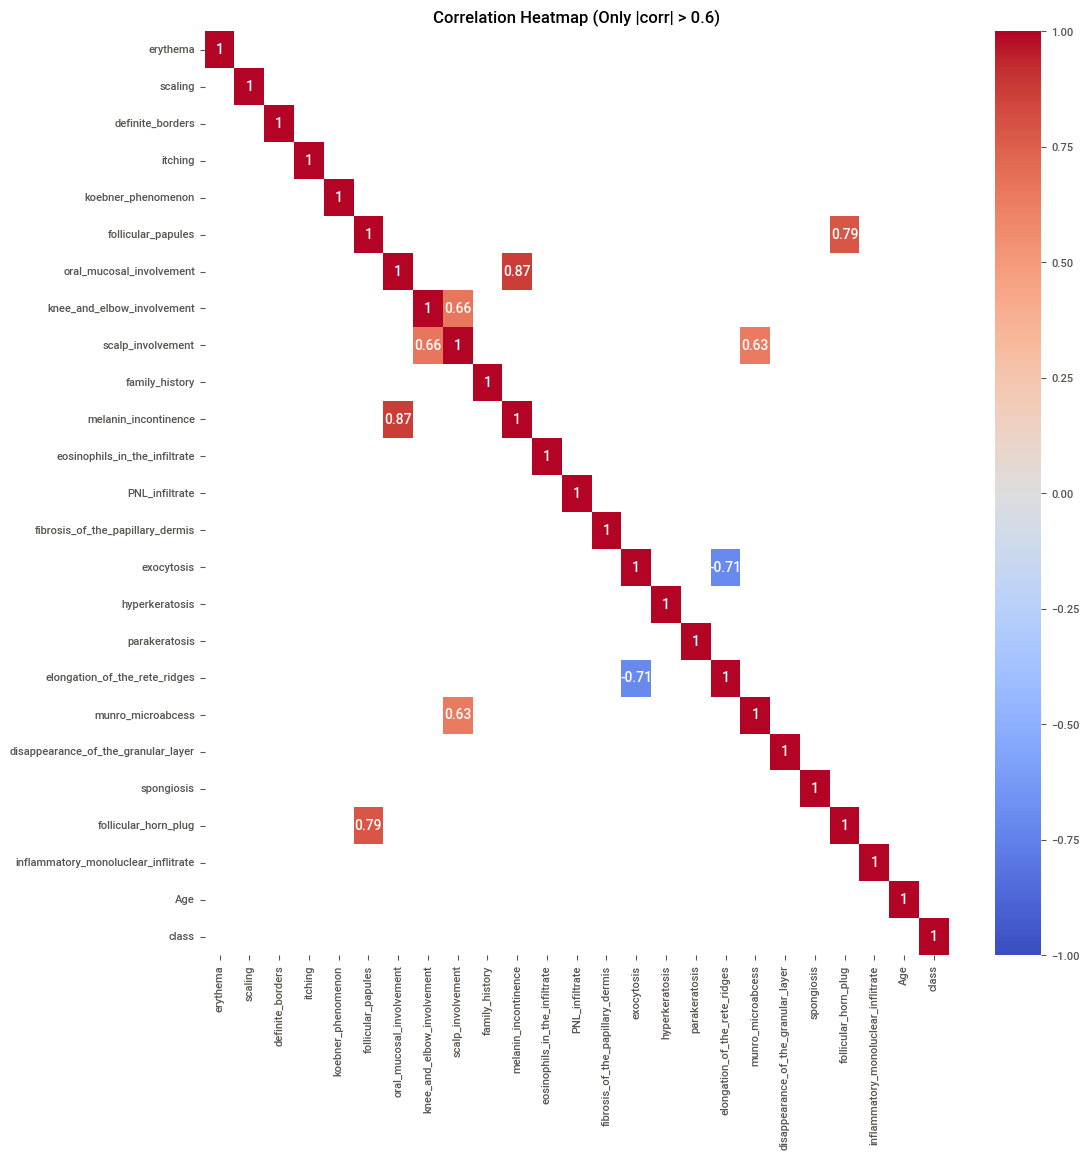

In [25]:
corr = data.drop(drop_list, axis=1).corr()

# keep only correlations > 0.6 or < -0.6
filtered = corr[(corr.abs() > 0.6)]

filtered = filtered.dropna(how='all', axis=0)
filtered = filtered.dropna(how='all', axis=1)

plt.figure(figsize=(12, 12))
sns.heatmap(filtered, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Only |corr| > 0.6)")
plt.show()

## Try without drop correlated columns

In [26]:
X = data.drop("class", axis = 1)
y = data['class']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=16)

In [28]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.9864864864864865
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5

    accuracy                           0.99        74
   macro avg       0.99      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74



In [29]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.972972972972973
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  0  0  0  9  0]
 [ 0  1  0  0  0  4]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       0.92      0.92      0.92        12
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00         9
           6       1.00      0.80      0.89         5

    accuracy                           0.97        74
   macro avg       0.97      0.95      0.96        74
weighted avg       0.97      0.97      0.97        74



## Try with drop correlated columns

In [30]:
drop_list.append('class')

In [31]:
X = data.drop(drop_list, axis=1)
y = data['class']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=16)

In [33]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.9864864864864865
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5

    accuracy                           0.99        74
   macro avg       0.99      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74



In [34]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.9324324324324325
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0  9  0  2  0  1]
 [ 0  1 12  0  0  0]
 [ 0  0  0 13  0  1]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       0.90      0.75      0.82        12
           3       1.00      0.92      0.96        13
           4       0.87      0.93      0.90        14
           5       1.00      1.00      1.00         9
           6       0.71      1.00      0.83         5

    accuracy                           0.93        74
   macro avg       0.91      0.93      0.92        74
weighted avg       0.94      0.93      0.93        74



In [43]:
# Random forest
random_model = RandomForestClassifier()
random_model.fit(X_train,y_train)

y_predict_random = random_model.predict(X_test)
y_proba_random = random_model.predict_proba(X_test)[:,1]
print("Random forest fitted")


# Gaussain NB
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)

y_predict_nb = nb_model.predict(X_test)
# y_proba_nb = nb_model.predict_proba(X_test)[:,1]
print("Gaussain NB fitted")

# Gradiant Boosting
gradient_model = GradientBoostingClassifier()
gradient_model.fit(X_train,y_train)

y_predict_gradient = gradient_model.predict(X_test)
y_proba_gradient = gradient_model.predict_proba(X_test)[:,1]
print("Gradiant Boosting fitted")

# SVC
svc_model = SVC()
svc_model.fit(X_train,y_train)

y_predict_svc = svc_model.predict(X_test)
y_proba_svc = svc_model
print("SVC fitted")

Random forest fitted
Gaussain NB fitted
Gradiant Boosting fitted
SVC fitted


In [48]:
print("Result of Random Forest model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_random))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_random))
print("Classification report :- \n", classification_report(y_test,y_predict_random))
print("\n\n")


print("Result of Gaussain NB model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_nb))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_nb))
print("Classification report :- \n", classification_report(y_test,y_predict_nb))
print("\n\n")


print("Result of Gradiant Boosting model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_gradient))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_gradient))
print("Classification report :- \n", classification_report(y_test,y_predict_gradient))
print("\n\n")


print("Result of SVC model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_svc))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_svc))
print("Classification report :- \n", classification_report(y_test,y_predict_svc))

Result of Random Forest model
Accuracy score :-  0.9864864864864865
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5

    accuracy                           0.99        74
   macro avg       0.99      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74




Result of Gaussain NB model
Accuracy score :-  0.8378378378378378
Confusion matrix :- 
 [[21  0  0  0  0  0]
 [ 0  1  0 11  0  0]
 [ 0  0 13  0  0  0]
 [ 1  0  0 13  0  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0 

In [49]:
# Logistic is best model for this data

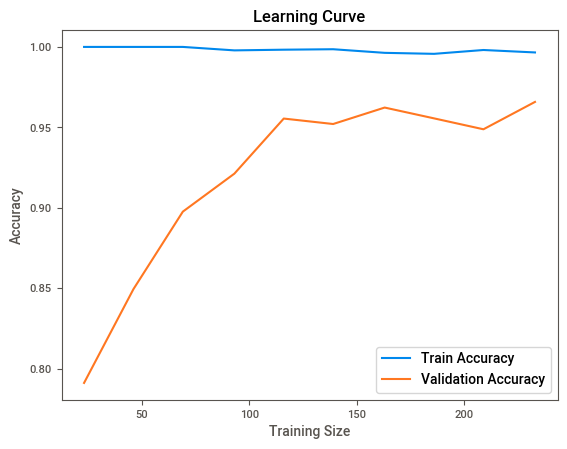

In [53]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=2000),
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()


In [50]:
from sklearn.model_selection import cross_val_score
cv_acc = cross_val_score(LogisticRegression(max_iter=2000), X_train, y_train, cv=5)
print(cv_acc.mean(), cv_acc.std())


0.9658094681472823 0.010629987183532096


In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)


{'C': 1, 'penalty': 'l2', 'solver': 'saga'} 0.9691992986557569


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_train, y_train, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),  # 8 points from 10% to 100%
        cv=5,                                  # 5-fold CV
        scoring='accuracy',
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, marker='o', label='Train Accuracy')
    plt.plot(train_sizes, val_mean,   marker='o', label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


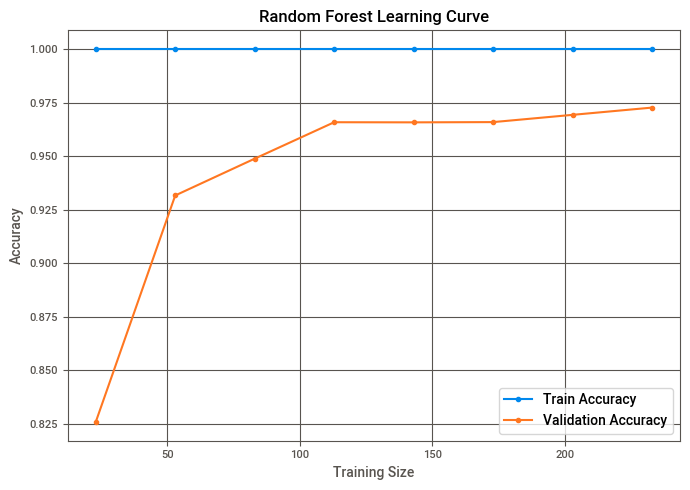

Random Forest Accuracy: 0.9864864864864865

Random Forest Confusion Matrix:
 [[21  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  0  0  0  9  0]
 [ 0  0  0  0  0  5]]

Random Forest Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        21
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00        13
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5

    accuracy                           0.99        74
   macro avg       0.99      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74



In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- define model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# --- plot learning curve
plot_learning_curve(rf_model, X_train, y_train, title="Random Forest Learning Curve")

# --- fit on full training data
rf_model.fit(X_train, y_train)

# --- evaluate on test
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)   # if y was 1..6, now it becomes 0..5

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


In [58]:
from xgboost import XGBClassifier

num_classes = len(le.classes_)  # should be 6

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)


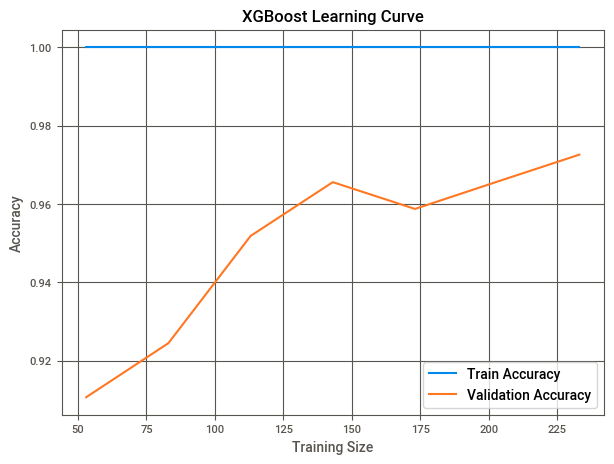

In [59]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X_train, y_train, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5,
        scoring='accuracy',
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, label='Train Accuracy')
    plt.plot(train_sizes, val_mean,   label='Validation Accuracy')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(xgb_model, X_train, y_train, "XGBoost Learning Curve")


In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9459459459459459
Confusion matrix:
 [[23  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  1  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.91      0.83      0.87        12
           2       1.00      0.93      0.97        15
           3       0.82      0.90      0.86        10
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.94      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74



In [63]:
# our model is ready for prediction. but task 3 we want doctor will know eriliast so we'll create model according to that

# Task 3 

* according to that we'll remove Histopathological Attributes and train model

In [64]:
data

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_the_infiltrate,PNL_infiltrate,fibrosis_of_the_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_of_the_rete_ridges,elongation_of_the_rete_ridges,thinning_of_the_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,0,2,2,0,0,3,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,0,2,0,0,0,3,2,0,0,0,0,0,0,0,3,0,2,0,1,0,0,2,3,50,3


In [75]:
data.columns[1:10]

Index(['scaling', 'definite_borders', 'itching', 'koebner_phenomenon',
       'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement',
       'knee_and_elbow_involvement', 'scalp_involvement'],
      dtype='object')

In [78]:
X = data[['scaling', 'definite_borders', 'itching', 'koebner_phenomenon','polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement','knee_and_elbow_involvement', 'scalp_involvement', 'Age']]
y = data['class']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=16)

In [81]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.918918918918919
Confusion matrix :- 
 [[20  1  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  2  0 12  0  0]
 [ 0  1  0  1  7  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      0.95      0.98        21
           2       0.73      0.92      0.81        12
           3       1.00      1.00      1.00        13
           4       0.86      0.86      0.86        14
           5       1.00      0.78      0.88         9
           6       1.00      1.00      1.00         5

    accuracy                           0.92        74
   macro avg       0.93      0.92      0.92        74
weighted avg       0.93      0.92      0.92        74



In [82]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict))
# print("recall :- ", recall_score(y_test,y_predict))
# print("f1 score :- ", f1_score(y_test,y_predict))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict))
print("Classification report :- \n", classification_report(y_test,y_predict))

Accuracy score :-  0.8378378378378378
Confusion matrix :- 
 [[17  1  0  1  0  2]
 [ 1  9  0  1  1  0]
 [ 0  0 12  1  0  0]
 [ 0  1  0 13  0  0]
 [ 0  0  0  2  7  0]
 [ 1  0  0  0  0  4]]
Classification report :- 
               precision    recall  f1-score   support

           1       0.89      0.81      0.85        21
           2       0.82      0.75      0.78        12
           3       1.00      0.92      0.96        13
           4       0.72      0.93      0.81        14
           5       0.88      0.78      0.82         9
           6       0.67      0.80      0.73         5

    accuracy                           0.84        74
   macro avg       0.83      0.83      0.83        74
weighted avg       0.85      0.84      0.84        74



In [83]:
# Random forest
random_model = RandomForestClassifier()
random_model.fit(X_train,y_train)

y_predict_random = random_model.predict(X_test)
y_proba_random = random_model.predict_proba(X_test)[:,1]
print("Random forest fitted")


# Gaussain NB
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)

y_predict_nb = nb_model.predict(X_test)
# y_proba_nb = nb_model.predict_proba(X_test)[:,1]
print("Gaussain NB fitted")

# Gradiant Boosting
gradient_model = GradientBoostingClassifier()
gradient_model.fit(X_train,y_train)

y_predict_gradient = gradient_model.predict(X_test)
y_proba_gradient = gradient_model.predict_proba(X_test)[:,1]
print("Gradiant Boosting fitted")

# SVC
svc_model = SVC()
svc_model.fit(X_train,y_train)

y_predict_svc = svc_model.predict(X_test)
y_proba_svc = svc_model
print("SVC fitted")

Random forest fitted
Gaussain NB fitted
Gradiant Boosting fitted
SVC fitted


In [84]:
print("Result of Random Forest model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_random))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_random))
print("Classification report :- \n", classification_report(y_test,y_predict_random))
print("\n\n")


print("Result of Gaussain NB model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_nb))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_nb))
print("Classification report :- \n", classification_report(y_test,y_predict_nb))
print("\n\n")


print("Result of Gradiant Boosting model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_gradient))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_gradient))
print("Classification report :- \n", classification_report(y_test,y_predict_gradient))
print("\n\n")


print("Result of SVC model")
print("Accuracy score :- ", accuracy_score(y_test,y_predict_svc))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_svc))
print("Classification report :- \n", classification_report(y_test,y_predict_svc))

Result of Random Forest model
Accuracy score :-  0.8918918918918919
Confusion matrix :- 
 [[20  0  0  1  0  0]
 [ 0  9  0  2  1  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0 13  0  0]
 [ 0  0  0  3  6  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      0.95      0.98        21
           2       0.90      0.75      0.82        12
           3       1.00      1.00      1.00        13
           4       0.68      0.93      0.79        14
           5       0.86      0.67      0.75         9
           6       1.00      1.00      1.00         5

    accuracy                           0.89        74
   macro avg       0.91      0.88      0.89        74
weighted avg       0.91      0.89      0.89        74




Result of Gaussain NB model
Accuracy score :-  0.7432432432432432
Confusion matrix :- 
 [[19  1  0  1  0  0]
 [ 0  1  0  9  2  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0 14  0  0]
 [ 0  1  0  5  3  0]
 [ 0  0  0  0  0 

In [85]:
# Logistic is best model

# Hyperparameter tunning in Logistic model

In [88]:
param_dist = {
    'C' : [0.001,0.01,0.05,0.1,0.5,1],
    'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'solver' : ['saga', 'liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter' : [100,200,500]
}

gs_logis = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_dist,
    scoring = 'accuracy',
    n_jobs=-1,
    verbose=2,
    refit=True,
    cv=5,
)

gs_logis.fit(X_train,y_train)
y_predict_gs_logis = gs_logis.predict(X_test)

print("Accuracy score :- ", accuracy_score(y_test,y_predict_gs_logis))
print("Confusion matrix :- \n", confusion_matrix(y_test,y_predict_gs_logis))
print("Classification report :- \n", classification_report(y_test,y_predict_gs_logis))

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Accuracy score :-  0.918918918918919
Confusion matrix :- 
 [[20  1  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  0]
 [ 0  2  0 12  0  0]
 [ 0  1  0  1  7  0]
 [ 0  0  0  0  0  5]]
Classification report :- 
               precision    recall  f1-score   support

           1       1.00      0.95      0.98        21
           2       0.73      0.92      0.81        12
           3       1.00      1.00      1.00        13
           4       0.86      0.86      0.86        14
           5       1.00      0.78      0.88         9
           6       1.00      1.00      1.00         5

    accuracy                           0.92        74
   macro avg       0.93      0.92      0.92        74
weighted avg       0.93      0.92      0.92        74



In [89]:
gs_logis.best_params_

{'C': 1,
 'class_weight': 'balanced',
 'max_iter': 100,
 'penalty': 'l2',
 'solver': 'liblinear'}

In [90]:
gs_logis.best_score_

0.8767971946230275

In [91]:
import numpy as np

logis = gs_logis.best_estimator_   # your tuned LogisticRegression
feature_names = X_train.columns    # assuming X_train is a DataFrame

# coef_.shape = (n_classes, n_features)
coefs = logis.coef_
classes = logis.classes_

for i, cls in enumerate(classes):
    coef_i = coefs[i]
    idx_sorted = np.argsort(coef_i)[::-1]   # largest positive first
    top_idx = idx_sorted[:10]
    print(f"\nTop features increasing probability of class {cls}:")
    for j in top_idx:
        print(f"  {feature_names[j]}  (coef = {coef_i[j]:.3f})")



Top features increasing probability of class 1:
  scalp_involvement  (coef = 1.795)
  knee_and_elbow_involvement  (coef = 1.240)
  definite_borders  (coef = 0.810)
  koebner_phenomenon  (coef = 0.378)
  Age  (coef = -0.001)
  scaling  (coef = -0.204)
  itching  (coef = -0.475)
  oral_mucosal_involvement  (coef = -0.506)
  polygonal_papules  (coef = -1.103)
  follicular_papules  (coef = -2.095)

Top features increasing probability of class 2:
  scaling  (coef = 1.319)
  itching  (coef = 0.043)
  Age  (coef = -0.015)
  oral_mucosal_involvement  (coef = -0.619)
  definite_borders  (coef = -0.655)
  scalp_involvement  (coef = -0.665)
  polygonal_papules  (coef = -0.909)
  knee_and_elbow_involvement  (coef = -1.252)
  follicular_papules  (coef = -1.321)
  koebner_phenomenon  (coef = -2.003)

Top features increasing probability of class 3:
  polygonal_papules  (coef = 2.621)
  oral_mucosal_involvement  (coef = 1.826)
  koebner_phenomenon  (coef = 0.090)
  definite_borders  (coef = 0.058)
  

In [95]:
y_proba_gs_logis = gs_logis.predict_proba(X_test)

In [96]:
y_proba_gs_logis

array([[1.36110363e-02, 7.25567188e-01, 1.27991456e-02, 5.89416865e-02,
        1.83127197e-01, 5.95374575e-03],
       [1.05060304e-01, 4.80631318e-02, 6.70548304e-02, 7.21539160e-01,
        3.73878193e-02, 2.08947539e-02],
       [1.15497570e-02, 8.88772041e-01, 1.50773167e-03, 2.40441659e-02,
        7.41256594e-02, 6.45134608e-07],
       [3.46678064e-03, 7.37107721e-03, 9.87399701e-01, 3.38303806e-04,
        1.10402782e-03, 3.20109171e-04],
       [9.77119170e-02, 1.30382163e-01, 1.31701899e-02, 7.47234617e-01,
        1.14299645e-02, 7.11492905e-05],
       [7.02965803e-03, 8.82715947e-01, 2.39122258e-03, 9.11901613e-03,
        9.85478246e-02, 1.96331241e-04],
       [6.23425289e-01, 2.49591605e-01, 8.11273212e-03, 7.61664726e-02,
        4.27024477e-02, 1.45340047e-06],
       [9.91728692e-01, 1.11147893e-03, 5.61212751e-03, 1.67841696e-04,
        9.68438228e-04, 4.11421338e-04],
       [1.01010926e-01, 8.41187711e-03, 6.99284593e-01, 1.36934910e-01,
        5.43569769e-02, 

In [97]:
gs_logis.classes_

array([1, 2, 3, 4, 5, 6], dtype=int64)

In [98]:
def show_prediction_details(model, X, row_index):
    proba = model.predict_proba(X)[row_index]
    classes = model.classes_
    percentages = proba * 100

    sorted_idx = np.argsort(percentages)[::-1]

    print(f"\nPrediction Probability for Row {row_index}:")
    for idx in sorted_idx:
        print(f"Class {classes[idx]} → {percentages[idx]:.2f}%")

In [123]:
show_prediction_details(gs_logis, [[1,1,0,1,0,0,0,0,0,12]], 0)


Prediction Probability for Row 0:
Class 4 → 72.15%
Class 1 → 10.51%
Class 3 → 6.71%
Class 2 → 4.81%
Class 5 → 3.74%
Class 6 → 2.09%


In [124]:
show_prediction_details(gs_logis, X_test, 0)


Prediction Probability for Row 0:
Class 2 → 72.56%
Class 5 → 18.31%
Class 4 → 5.89%
Class 1 → 1.36%
Class 3 → 1.28%
Class 6 → 0.60%


In [121]:
X_test.head()[1:2]

,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,Age
308,1,1,0,1,0,0,0,0,0,12


In [114]:
y_test

164    2
308    4
156    2
288    3
219    4
      ..
242    1
25     1
129    4
178    3
3      1
Name: class, Length: 74, dtype: int64